# Tutorial 2– Simple Regressions

### This notebook contains all the sample code for simple linear regression and ridge regression.
#### You will learn:
1. Linear regression models
2. Linear regression models with regularizations
3. Linear regression for real data analysis
4. Evaluation metrics for regression analysis

#### Summary of toolbox (for review purposes):
1. Visualization: matplotlib (https://matplotlib.org/stable/plot_types/index.html)
2. Linear regression (OLS and Ridge) from sklearn: from sklearn.linear_model import LinearRegression (https://scikit-learn.org/stable/modules/linear_model.html)
3. Data processing for categorical variables: from sklearn.preprocessing import OneHotEncoder (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
4. Data split for validation (to be continued in week 10): from sklearn.model_selection import train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

# Linear regression using the Normal Equation

## First, let's generate a dataset for linear regression: $y=3*x+4+\epsilon$

In [1]:
import numpy.random as rnd # This is a library for random number generation
X = 2 * rnd.rand(100, 1)
y = 4 + 3 * X + rnd.randn(100, 1)

## Let's take a look at the data distribution

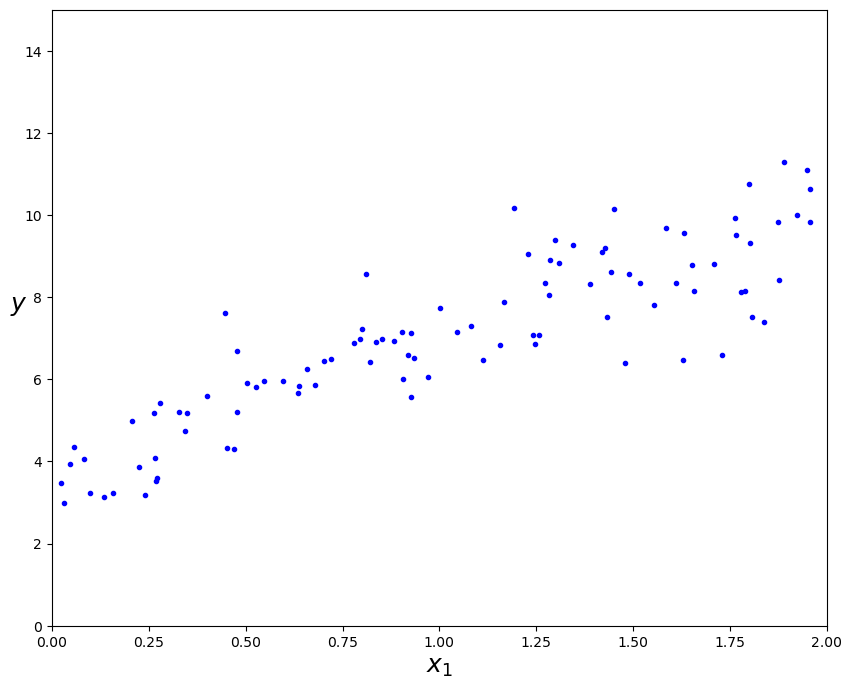

In [2]:
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 8
## "b." blue dots
plt.plot(X, y, "b.")
#plt.plot(X, y, color="blue", marker=".")
# $...$ tells Matplotlib to interpret the text as mathematical notation using its mathtext system
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.savefig("generated_data_plot.png")
plt.show()

## Next, we use the LinearRegression model from the sklearn library to fit a linear regression model to our data. The fitted model gives us the regression line.

In [3]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() # Define your model
lin_reg.fit(X, y)  # Fit your model using the data

LinearRegression()

In [4]:
print(lin_reg.__dict__)

{'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False, 'n_features_in_': 1, 'coef_': array([[3.08846435]]), 'rank_': 1, 'singular_': array([5.78736847]), 'intercept_': array([3.87641727])}


In [5]:
#This step shows the intercept and coefficients of your fit result
print('Slope is %f, Intercept is %f'%(lin_reg.coef_[0][0], lin_reg.intercept_[0]))
print('Linear Function is y=%f * x + %f'%(lin_reg.coef_[0][0], lin_reg.intercept_[0]))

Slope is 3.088464, Intercept is 3.876417
Linear Function is y=3.088464 * x + 3.876417


## After the model is trained, we can use it to predict the Y values of new data points given X values

We can see the regression line predict the Y-values as the black dot. The real Y values are represented as yellow stars.

C:\Users\sophi\AppData\Local\Temp\ipykernel_35816\2828062659.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X_new,Y_new_predict,"b.",color='black',markersize=16)


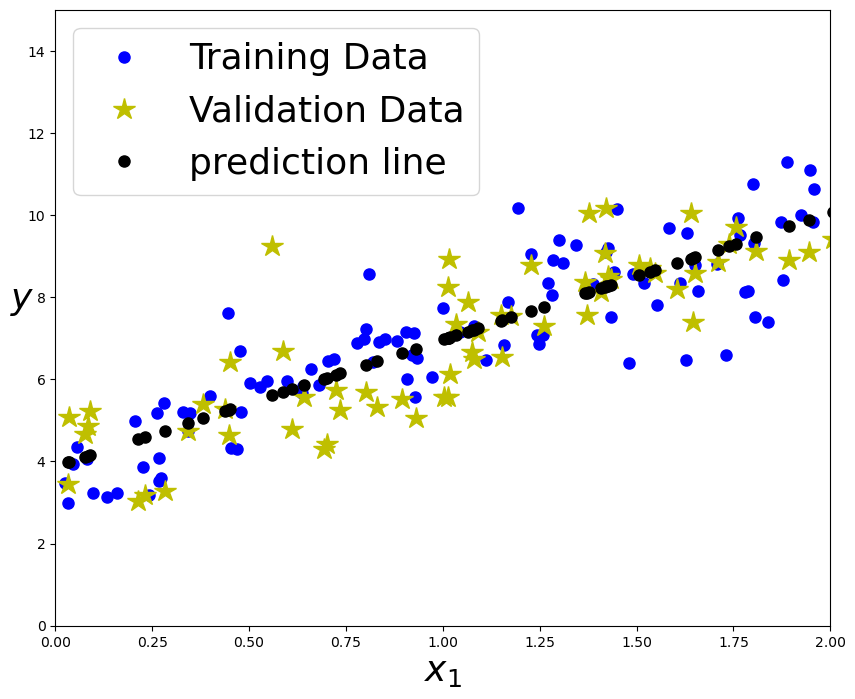

In [6]:
X_new=3 * rnd.rand(100, 1) # We generate a set of new data points of X
Y_new = 4 + 3 * X_new + rnd.randn(100, 1) # We generate a set of new data points of Y

# We use the regression model to predict the Y value of the new data points
Y_new_predict=lin_reg.predict(X_new)

plt.plot(X, y, "b.",markersize=16)
plt.plot(X_new,Y_new,"*",color='y',markersize=16)
plt.plot(X_new,Y_new_predict,"b.",color='black',markersize=16)
plt.xlabel("$x_1$", fontsize=26)
plt.ylabel("$y$", rotation=0, fontsize=26)
plt.axis([0, 2, 0, 15])
plt.legend(['Training Data','Validation Data','prediction line'],fontsize=26)
plt.show()

## Evaluate the performance of regression line using new data points.
Here we can use some evaluation metric to evaluate the performance of your data.
We try R-square to evaluate.
Check https://scikit-learn.org/stable/modules/model_evaluation.html#the-scoring-parameter-defining-model-evaluation-rules for more evaluation metrics

In [7]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
evaluation_result=r2_score(Y_new, Y_new_predict)
print('R2=%f' %evaluation_result)
evaluation_result=mean_absolute_error(Y_new, Y_new_predict)
print('Mean absolute error=%f' %evaluation_result)

R2=0.870716
Mean absolute error=0.828464


# Deal with model complexity - Ridge Regression
reference: https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/

## Let's first generate a dataset based on y=Sin(x)+noise and use it for model fitting.

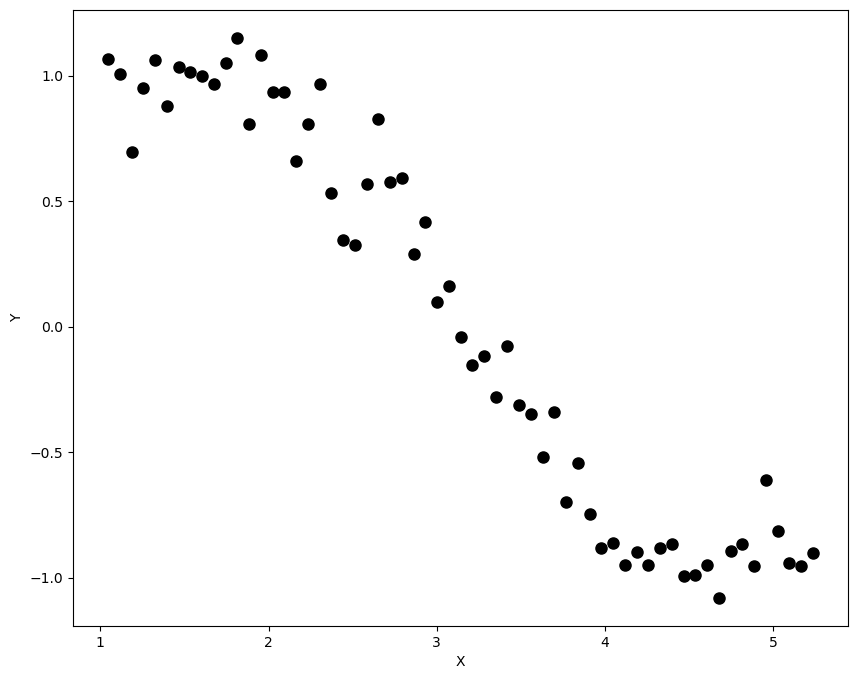

          x         y       x^2       x^3       x^4       x^5       x^6  \
0  1.047198  1.065763  1.096623  1.148381  1.202581  1.259340  1.318778   
1  1.117011  1.006086  1.247713  1.393709  1.556788  1.738948  1.942424   
2  1.186824  0.695374  1.408551  1.671702  1.984016  2.354677  2.794587   
3  1.256637  0.949799  1.579137  1.984402  2.493673  3.133642  3.937850   
4  1.326450  1.063496  1.759470  2.333850  3.095735  4.106339  5.446854   

        x^7       x^8        x^9       x^10       x^11       x^12       x^13  \
0  1.381021  1.446202   1.514459   1.585938   1.660790   1.739176   1.821260   
1  2.169709  2.423588   2.707173   3.023942   3.377775   3.773011   4.214494   
2  3.316683  3.936319   4.671717   5.544505   6.580351   7.809718   9.268760   
3  4.948448  6.218404   7.814277   9.819710  12.339811  15.506664  19.486248   
4  7.224981  9.583578  12.712139  16.862020  22.366630  29.668222  39.353420   

        x^14       x^15  
0   1.907219   1.997235  
1   4.707635   5

In [8]:
#Import the libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

#Define input array with angles from 60° to 300°, converted from degrees to radians.
x = np.array([i*np.pi/180 for i in range(60,304,4)])
np.random.seed(10)  #Sets the random seed for NumPy's random-number generator.
# np.random.normal(mean, standard_deviation, number_of_values)
y = np.sin(x) + np.random.normal(0,0.15,len(x))
#column_stack() combines the two arrays side by side as columns.
data = pd.DataFrame(np.column_stack([x,y]),columns=['x','y'])

plt.plot(data['x'],data['y'],"k.",markersize=16)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

#Create polynomial variables (x^2, x^3, ..., x^{15}) in your DataFrame.
for i in range(2,16):  #power of 1 is already there
    colname = 'x^%d'%i      #new var will be x_powerb
    data[colname] = data['x']**i
print(data.head())

## We can use a complex models to fit, which may have overfitting issue:

for example, we can use **polynomial regression**:

$$y=a0+a1*x + a2*x^2+a3*x^3+...a15*x^{15}$$


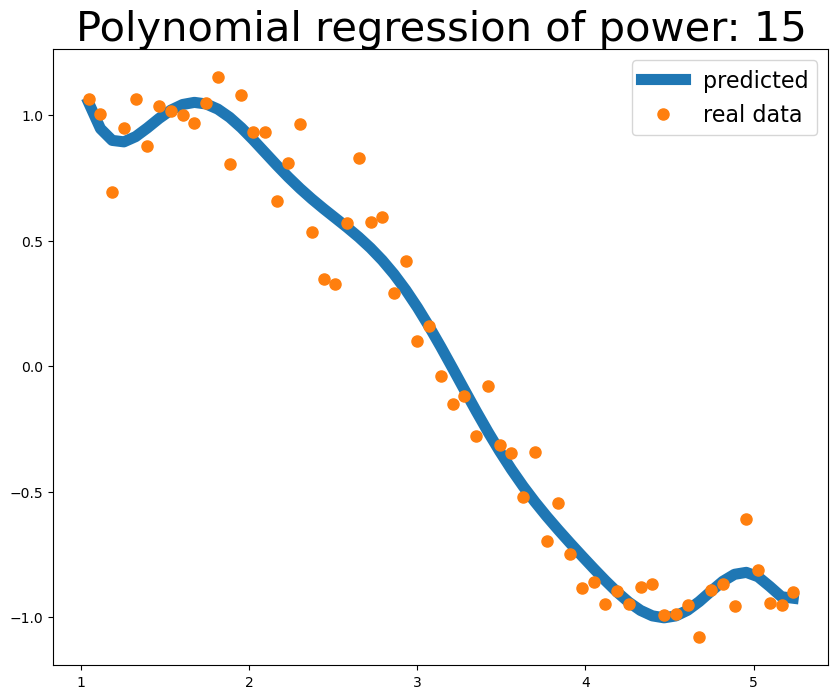

Lets take a look at the coefficients:
intercept=12.367975
a1=-13.257106
a2=-7.140650
a3=5.535653
a4=9.289331
a5=-0.529531
a6=-9.011442
a7=0.253921
a8=8.954160
a9=-8.142741
a10=3.699555
a11=-1.021597
a12=0.179302
a13=-0.019634
a14=0.001228
a15=-0.000034


In [9]:
from sklearn.linear_model import LinearRegression
power=15
predictors=['x']
predictors.extend(['x^%d'%i for i in range(2,power+1)])
linreg = LinearRegression()
linreg.fit(data[predictors],data['y'])
y_pred = linreg.predict(data[predictors])

plt.plot(data['x'],y_pred,linewidth=8)
plt.plot(data['x'],data['y'],'.',markersize=16)
plt.title('Polynomial regression of power: %d'%power,fontsize=30)
plt.legend(['predicted','real data'],fontsize=16)
plt.show()


print('Lets take a look at the coefficients:')
print('intercept=%f' %linreg.intercept_)
for i in range(len(linreg.coef_)):
    print('a%d=%f' %(i+1,linreg.coef_[i]))

## Ridge regression sets a penalty to coefficient size:
## Regression penalty: α * (sum of squares of coefficients)

C:\Users\sophi\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.47936e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


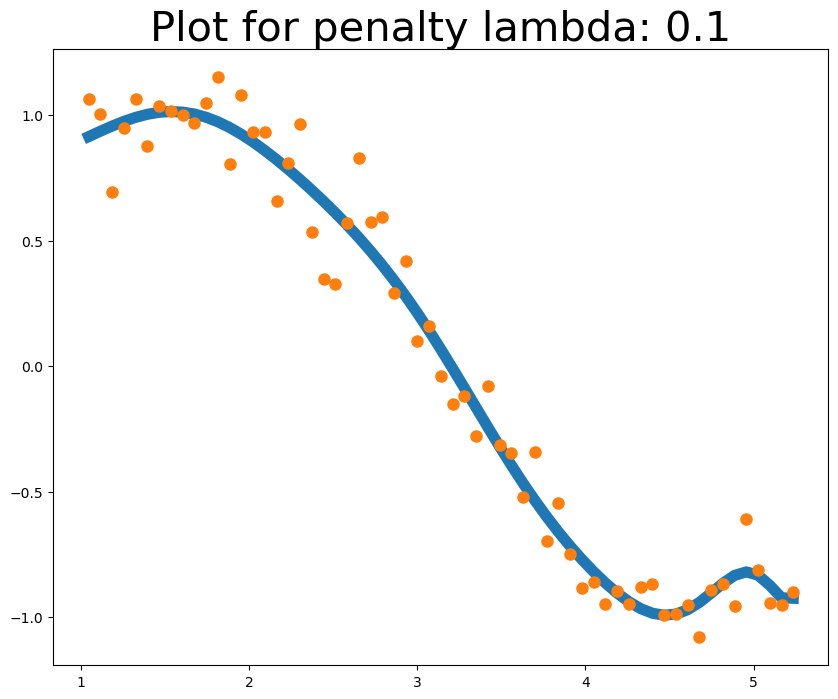

Lets take a look at the coefficients:
intercept=0.788751
a1=-0.021043
a2=0.006600
a3=0.063724
a4=0.101482
a5=0.063904
a6=-0.050368
a7=-0.115335
a8=-0.010430
a9=0.172735
a10=-0.149777
a11=0.062788
a12=-0.015190
a13=0.002171
a14=-0.000171
a15=0.000006


In [10]:
from sklearn.linear_model import Ridge
alpha=0.1
#Fit the model
ridgereg = Ridge(alpha=alpha)
ridgereg.fit(data[predictors],data['y'])
y_pred = ridgereg.predict(data[predictors])
    
#Check if a plot is to be made for the entered alpha
plt.plot(data['x'],y_pred,linewidth=8)
plt.plot(data['x'],data['y'],'.',markersize=16)
plt.title('Plot for penalty lambda: %.3g'%alpha,fontsize=30)
plt.show()
print('Lets take a look at the coefficients:')
print('intercept=%f' %ridgereg.intercept_)
for i in range(len(ridgereg.coef_)):
    print('a%d=%f' %(i+1,ridgereg.coef_[i]))

In [11]:
alphas = [0.001, 0.01, 0.1]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(data[predictors],data['y'])

    y_pred = ridge.predict(data[predictors])

    r2 = r2_score(data['y'], y_pred)
    rmse = np.sqrt(mean_absolute_error(data['y'], y_pred))

    print(alpha, r2, rmse)

0.001 0.9758496554501757 0.3058679023154275
0.01 0.9726869604648501 0.3241968215625607
0.1 0.9750721154612126 0.30773850648704004


C:\Users\sophi\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.32267e-26): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\sophi\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.47936e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## The ridge regression can regularize the model complexity to avoid overfitting!

## 3.6 Real Data: Airbnb Price Prediction
#### Original dataset can be found here: https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction?resource=download

In [12]:
import pandas as pd
ResearchData=pd.read_csv('Airbnb.csv') #load data as pandas dataframe
ResearchData.head()

,id,log_price,property_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,number_of_reviews,review_scores_rating,bedrooms,beds
0,6901257,5.010635,Apartment,3,1.0,Real Bed,strict,True,NYC,t,t,2,100.0,1,1
1,6304928,5.129899,Apartment,7,1.0,Real Bed,strict,True,NYC,t,f,6,93.0,3,3
2,7919400,4.976734,Apartment,5,1.0,Real Bed,moderate,True,NYC,t,t,10,92.0,1,3
3,13418779,6.620073,House,4,1.0,Real Bed,flexible,True,SF,t,t,0,NaN,2,2
4,3808709,4.744932,Apartment,2,1.0,Real Bed,moderate,True,DC,t,t,4,40.0,0,1


In [13]:
feature=['property_type','accommodates','bathrooms','bedrooms','beds']
target='log_price'
x=ResearchData[feature]
y=ResearchData[target]
x['property_type'].drop_duplicates()

0     Apartment
3         House
15         Loft
16    Townhouse
Name: property_type, dtype: object

### Categorical variable
As the attribute (IV) 'property_type' is categorical, we need to create a dummy for it.

In [14]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='first')
enc_f=enc.fit(x[['property_type']])
print(enc_f.categories_) #It will generate four dummies, alphabetically sorted ['Apartment', 'House', 'Loft', 'Townhouse'] 
# The first category "Apartment" will be dropped.

enc_df = pd.DataFrame(enc_f.transform(x[['property_type']]).toarray())
enc_df.columns = ['House', 'Loft','Town House']
#columns=enc_f.get_feature_names_out(['property_type'])
enc_df.head()

[array(['Apartment', 'House', 'Loft', 'Townhouse'], dtype=object)]


,House,Loft,Town House
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0


In [15]:
# merge with main df on key values, this will be used as IV
x = x.join(enc_df)
x = x.drop('property_type', axis=1)
x.head()

,accommodates,bathrooms,bedrooms,beds,House,Loft,Town House
0,3,1.0,1,1,0.0,0.0,0.0
1,7,1.0,3,3,0.0,0.0,0.0
2,5,1.0,1,3,0.0,0.0,0.0
3,4,1.0,2,2,1.0,0.0,0.0
4,2,1.0,0,1,0.0,0.0,0.0


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, 
test_size=0.30, random_state=0)

lin_reg = LinearRegression() # define your model
lin_reg.fit(x_train, y_train)

print(lin_reg.coef_)
print(lin_reg.intercept_)

[ 0.17000603  0.13795161  0.12490194 -0.05628411 -0.19173624  0.12103869
 -0.17429126]
4.057529625004383


In [17]:
y_pred=lin_reg.predict(x_test)
comparison_df = pd.DataFrame({"Actual":y_test.tolist(),"Predicted":y_pred})
comparison_df

,Actual,Predicted
0,5.220356,6.376582
1,4.248495,4.729013
2,4.077537,4.853915
3,5.043425,4.774117
4,4.488636,4.604111
...,...,...
20435,4.442651,4.434105
20436,4.836282,5.240185
20437,5.521461,5.082075
20438,3.806662,4.242369


In [18]:
#use mean_absolute_error to evalute the prediction performance for new data.
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test,y_pred)
print(MAE)

0.4389203843146883


------------------------------------------------------------------------------------------

<div class="alert alert-block alert-success"> 🤖 AI Prompt (Copy this to AI):
Please generate a complete Jupyter Notebook for a regression analysis tutorial that covers:

1. Generating synthetic data: y = 3*x + 4 + ε with 100 samples
2. Visualizing the data with matplotlib
3. Fitting a LinearRegression model using sklearn
4. Extracting and displaying coefficients and intercept
5. Making predictions on new data (100 samples with x in [0, 3])
6. Visualizing training data, test data, and predictions
7. Evaluating model performance using R² and MAE
8. Generating a sin(x) dataset with noise (60° to 300°, step 4°)
9. Creating polynomial features (x² to x¹⁵)
10. Fitting polynomial regression (degree 15) to show overfitting
11. Implementing Ridge regression with alpha=0.1
12. Comparing Ridge regression with different alpha values [0.001, 0.01, 0.1]
13. Loading and preprocessing Airbnb dataset
14. Encoding categorical variables with OneHotEncoder
15. Splitting data for training (70%) and testing (30%)
16. Training and evaluating the Airbnb price prediction model

Include all necessary imports, clear comments, and proper formatting for Jupyter Notebook.
                                 </div>

# Summary
## Learn how to get linear regression models: 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

## Learn how to use different evaluation metrics for prediction
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

## Learn how to change the regularization penalties (the alpha)
ridge_reg = Ridge(alpha=1, solver="cholesky")

## After-class reading material:
Interested students may read this toolbox for alternative linear regression models:
https://www.statsmodels.org/stable/index.html 

------------------------------------------------------------------------------------------

## Week 2 Assignment

### 1. Dataset Generation (10 points)

Generate a training dataset based on the equation \(y = 10x + 15\), and generate a separate dataset for evaluation.

### 2. Model Evaluation Using MAE (10 points)

Use **Mean Absolute Error (MAE)** to evaluate the performance of the model developed in Question 1.

### 3. Ridge Regression (40 points)

In Section 3.4, **Ridge Regression**, try the following values of `alpha`: **0.001, 0.01, and 0.1**.

Evaluate the performance of the three Ridge Regression models and compare their results. Identify which `alpha` value provides the best model performance.

### 4. Airbnb Price Prediction (40 points)

In Section 3.6, **Airbnb Price Prediction**, add **`cancellation_policy`** as an additional predictor to the linear regression model.

Evaluate the performance of the new model and compare it with the original model.

### Submission

Upload your **code and results as an HTML file** to **Canvas**.
